In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\tm610\OneDrive\Desktop\code-alpha-projects\credit_scoring_dataset.csv")
df

,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Risk
0,58,Male,0,Free,Quite Rich,Little,8314,14,Personal,Good
1,24,Male,3,Own,Little,Little,8164,20,Electronics,Bad
2,56,Male,1,Free,Rich,Little,15719,43,Business,Bad
3,69,Male,1,Free,Rich,Moderate,10105,15,Education,Good
4,66,Female,0,Own,Rich,Little,12763,60,Business,Bad
...,...,...,...,...,...,...,...,...,...,...
495,59,Female,1,Free,Little,Little,6142,38,Home,Bad
496,49,Male,0,Rent,Quite Rich,Little,11842,23,Car,Good
497,50,Male,3,Rent,Moderate,Little,16043,34,Electronics,Bad
498,46,Male,3,Rent,Quite Rich,Little,17297,53,Personal,Bad


In [3]:
print(df.head)

<bound method NDFrame.head of      Age     Sex  Job Housing Saving_accounts Checking_account  Credit_amount  \
0     58    Male    0    Free      Quite Rich           Little           8314   
1     24    Male    3     Own          Little           Little           8164   
2     56    Male    1    Free            Rich           Little          15719   
3     69    Male    1    Free            Rich         Moderate          10105   
4     66  Female    0     Own            Rich           Little          12763   
..   ...     ...  ...     ...             ...              ...            ...   
495   59  Female    1    Free          Little           Little           6142   
496   49    Male    0    Rent      Quite Rich           Little          11842   
497   50    Male    3    Rent        Moderate           Little          16043   
498   46    Male    3    Rent      Quite Rich           Little          17297   
499   19    Male    3    Rent          Little             Rich          18992  

In [4]:
print(df.shape)

(500, 10)


In [5]:
print(df.columns)

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account',
       'Credit_amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               500 non-null    int64 
 1   Sex               500 non-null    object
 2   Job               500 non-null    int64 
 3   Housing           500 non-null    object
 4   Saving_accounts   500 non-null    object
 5   Checking_account  500 non-null    object
 6   Credit_amount     500 non-null    int64 
 7   Duration          500 non-null    int64 
 8   Purpose           500 non-null    object
 9   Risk              500 non-null    object
dtypes: int64(4), object(6)
memory usage: 39.2+ KB
None


In [7]:
print(df.describe())

              Age         Job  Credit_amount    Duration
count  500.000000  500.000000     500.000000  500.000000
mean    43.728000    1.440000   11095.772000   34.292000
std     15.237927    1.124691    5232.774408   15.994574
min     18.000000    0.000000    1087.000000    6.000000
25%     30.000000    0.000000    6669.750000   21.000000
50%     44.000000    1.000000   11193.000000   34.000000
75%     57.250000    2.000000   15551.250000   49.000000
max     70.000000    3.000000   19955.000000   60.000000


EDA

In [8]:
print(df.isnull().sum())

Age                 0
Sex                 0
Job                 0
Housing             0
Saving_accounts     0
Checking_account    0
Credit_amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [9]:
print(df["Risk"].value_counts())

Risk
Bad     353
Good    147
Name: count, dtype: int64


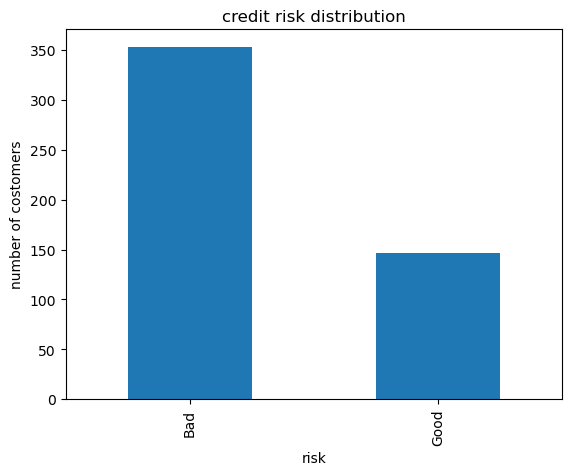

In [10]:
df["Risk"].value_counts().plot(kind="bar")
plt.title("credit risk distribution")
plt.xlabel("risk")
plt.ylabel("number of costomers")
plt.show()

In [11]:
print(df.isnull().sum())

Age                 0
Sex                 0
Job                 0
Housing             0
Saving_accounts     0
Checking_account    0
Credit_amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [12]:
print(df.dtypes)

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving_accounts     object
Checking_account    object
Credit_amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = [
    "Sex",
    "Housing",
    "Saving_accounts",
    "Checking_account",
    "Purpose",
    "Risk"
]

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

print(df.head())

   Age  Sex  Job  Housing  Saving_accounts  Checking_account  Credit_amount  \
0   58    1    0        0                2                 0           8314   
1   24    1    3        1                0                 0           8164   
2   56    1    1        0                3                 0          15719   
3   69    1    1        0                3                 1          10105   
4   66    0    0        1                3                 0          12763   

   Duration  Purpose  Risk  
0        14        5     1  
1        20        3     0  
2        43        0     0  
3        15        2     1  
4        60        0     0  


In [14]:
print(df.head())

   Age  Sex  Job  Housing  Saving_accounts  Checking_account  Credit_amount  \
0   58    1    0        0                2                 0           8314   
1   24    1    3        1                0                 0           8164   
2   56    1    1        0                3                 0          15719   
3   69    1    1        0                3                 1          10105   
4   66    0    0        1                3                 0          12763   

   Duration  Purpose  Risk  
0        14        5     1  
1        20        3     0  
2        43        0     0  
3        15        2     1  
4        60        0     0  


In [15]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  Sex  Job  Housing  Saving_accounts  Checking_account  Credit_amount  \
0   58    1    0        0                2                 0           8314   
1   24    1    3        1                0                 0           8164   
2   56    1    1        0                3                 0          15719   
3   69    1    1        0                3                 1          10105   
4   66    0    0        1                3                 0          12763   

   Duration  Purpose  
0        14        5  
1        20        3  
2        43        0  
3        15        2  
4        60        0  

Target:
0    1
1    0
2    0
3    1
4    0
Name: Risk, dtype: int32


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 9)
Testing data: (100, 9)


In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [18]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[1 1 0 0 0 0 0 1 0 0]


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.91


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[66  7]
 [ 2 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        73
           1       0.78      0.93      0.85        27

    accuracy                           0.91       100
   macro avg       0.88      0.92      0.89       100
weighted avg       0.92      0.91      0.91       100



In [21]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.78


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.93


In [23]:
print("\nModel Comparison")
print("-------------------------")
print("Decision Tree :", accuracy_score(y_test, y_pred))
print("Logistic      :", accuracy_score(y_test, lr_pred))
print("Random Forest :", accuracy_score(y_test, rf_pred))


Model Comparison
-------------------------
Decision Tree : 0.91
Logistic      : 0.78
Random Forest : 0.93


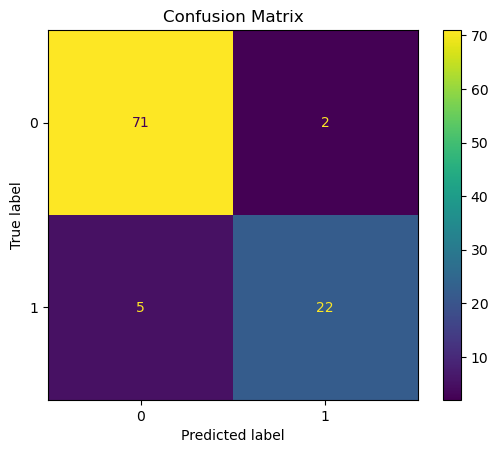

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [25]:
dt_acc = accuracy_score(y_test, y_pred)
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
print("Decision Tree :", dt_acc)
print("Logistic Regression :", lr_acc)
print("Random Forest :", rf_acc)
best = max({
    "Decision Tree": dt_acc,
    "Logistic Regression": lr_acc,
    "Random Forest": rf_acc
}, key=lambda k: {
    "Decision Tree": dt_acc,
    "Logistic Regression": lr_acc,
    "Random Forest": rf_acc
}[k])
print("Best Model:", best)

Decision Tree : 0.91
Logistic Regression : 0.78
Random Forest : 0.93
Best Model: Random Forest


In [26]:
from sklearn.metrics import roc_auc_score
y_prob = rf.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9857940131912734


Conclusion

A Credit Scoring Model was developed using Decision Tree, Logistic Regression, and Random Forest algorithms. After comparing their performance, the best-performing model was selected based on accuracy. The model can predict whether a customer is likely to have good or bad credit risk using customer financial information.